# Narrow-line subtraction — campaign mean spectrum

Follows the logic of `code_asymmetry.py:subtract_narrow_lines` step by step,
with Monte Carlo uncertainties — but with the **[OIII] steps decoupled from the
global continuum**: they run on the raw flux with their own local linear
continua, and the global continuum enters only the Hβ fit.

**This notebook runs FIRST in the workflow.** Step 0 (moved from
`spec_lc_pipeline`) stacks the AGN-only, **rest-frame** per-epoch combined
spectra into the campaign **mean & RMS spectra**, writes
`spec_mean_<line>.txt` / `spec_rms_<line>.txt`, and the narrow fit then runs
on that mean. `spec_lc_pipeline` and `measure_linewidth` load these files
back — they no longer build them.

**Input spectra are in REST-FRAME wavelength** (3 columns: wave, flux, err).
All windows below are rest-frame Angstrom.

Workflow: set the paths + windows in the config cell, run step 0 to build the
mean, run the quick-look cell to check the windows, then run the rest.
(Set `INPUT_DIR = None` to skip step 0 and fit an existing `SPEC_FILE`.)

Pipeline:
0. stack the per-epoch combined spectra → **mean & RMS spectra** (saved);
   the mean becomes the fit input
1. subtract [OIII]4959 from the **raw flux**, using the [OIII]5007 profile as
   template (free: wavelength shift, flux ratio, local linear background —
   the background absorbs the continuum under 4959)
2. extract the clean [OIII]5007 profile with its **own** local linear
   continuum — this is the narrow-line template
3. global linear continuum measured on the **narrow-subtracted** flux
   (continuum windows may sit near [OIII]: broad Hβ extends underneath, and
   the fitted narrow lines must not be double-counted), subtracted **only
   here**: fit the Hbeta window with (shifted/scaled template) + 2 Gaussians
   + constant, subtract only the narrow part

Uncertainties: flux perturbed by err x N(0,1), N_MC re-runs; per-pixel
scatter of the narrow model -> sigma; output error =
sqrt(err^2 + sigma_narrow^2).

Outputs:
- `spec_mean_<line>.txt`, `spec_rms_<line>.txt` — campaign mean & RMS spectra
  (wave, flux, err; raw flux units)
- `<spec>.subnarrow` — wave, narrow-subtracted flux (broad Hbeta +
  continuum kept), combined err
- `<OBJ>_narrow_profile.txt` — narrow model + components, each with 1-sigma
- `<OBJ>_oiii5007_template.txt` — clean template: wave, flux, err, sigma_MC

In [30]:
# ---------------- config: EDIT HERE ----------------
# all wavelengths REST-FRAME Angstrom

# --- step 0: build campaign mean & RMS spectra (moved from spec_lc_pipeline;
#     this notebook runs FIRST in the workflow). INPUT_DIR holds the AGN-only
#     REST-FRAME per-epoch combined spectra; FLUX_LST lists
#     <combined-name>  <JD> per row. Set INPUT_DIR = None to skip step 0 and
#     fit SPEC_FILE directly.
INPUT_DIR = '/Users/kaiwenzhang/Desktop/NGC 3227/Halpha_analysis/agn_only_dered_spectra'
FLUX_LST  = '/Users/kaiwenzhang/Desktop/NGC 3227/NGC3227/flux.lst'
LINE_NAME = 'hbeta'                  # tag: spec_mean_<line>.txt / spec_rms_<line>.txt
COMBINED_PATTERN = '_combined.txt'   # marks a per-epoch combined spectrum
EXCLUDE_SUBSTR   = ['rebin', '.out', '20200205']  # 20200205 = bad night (NGC3227)

# spectrum the narrow fit runs on; step 0 (if enabled) overrides this with
# the freshly built rest-frame mean
SPEC_FILE    = 'spec_mean_hbeta.txt'      # wave flux err
OBJ          = 'NGC3227'                  # tag for output file names

CONTI_LEFT   = (4780.0, 4800.0)   # left  global continuum window
CONTI_RIGHT  = (4950.0, 4970.0)   # right global continuum window
OIII5007_WIN = (4980.0, 5035.0)   # [OIII]5007 window = template extent
OIII4959_WIN = (4935.0, 4980.0)   # [OIII]4959 fit window
HB_WIN       = (4800.0, 4950.0)   # Hbeta fit window

N_MC = 500     # Monte Carlo realizations (0 = off)
SEED = 42
UNIT = 1.0e-14 # flux scale

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# Okabe-Ito colorblind-safe palette, fixed assignment
C_DATA   = '#000000'   # observed spectrum
C_MODEL  = '#E69F00'   # total model
C_BROAD  = '#0072B2'   # broad Hbeta
C_NARROW = '#009E73'   # narrow components / template
C_SUB    = '#D55E00'   # narrow-subtracted spectrum
C_CON    = '#CC79A7'   # continuum / background


def window_median(wave, flux, lim1, lim2):
    """Median flux and mean wavelength inside [lim1, lim2]."""
    idx = np.where((wave >= lim1) & (wave <= lim2))[0]
    if idx.size == 0:
        raise ValueError('empty window %.1f-%.1f' % (lim1, lim2))
    return np.median(flux[idx]), np.mean(wave[idx])


def linear_through(w1, f1, w2, f2, wave):
    return f1 + (f2 - f1) / (w2 - w1) * (wave - w1)


def gauss(w, area, center, sigma):
    """Gaussian with unit area scaled by `area`."""
    return area / np.sqrt(2.0 * np.pi) / sigma * \
        np.exp(-(w - center)**2 / 2.0 / sigma**2)


def fmt_par(par):
    if par.stderr is None:
        return '%.4f +/- n/a' % par.value
    return '%.4f +/- %.4f' % (par.value, par.stderr)

73 epochs | JD 2458803.01 -> 2458999.73
Stacked 73 spectra x 1907 pixels
median S/N of mean spectrum: nan
wrote spec_mean_hbeta.txt
wrote spec_rms_hbeta.txt


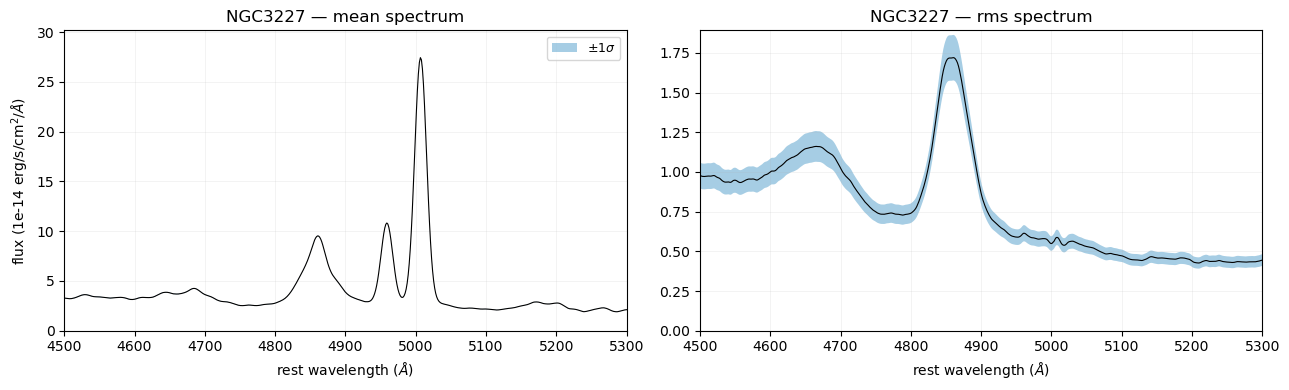

In [32]:
# ---------------- step 0: campaign mean & RMS spectra ----------------
# Moved from spec_lc_pipeline: this notebook runs FIRST in the workflow, so
# the campaign mean (narrow-fit input) and RMS (velocity-binning reference)
# are built here; spec_lc_pipeline and measure_linewidth load them back.
import os


def load_spectrum(path):
    """Return (wavelength, flux, err) sorted by wavelength.

    Robust to either (N, 3) column layout or (3, N) row layout.
    """
    arr = np.loadtxt(path)
    if arr.ndim != 2:
        raise ValueError('Spectrum %s is not 2-D (shape %s).' % (path, arr.shape))
    if arr.shape[1] == 3:        # (N, 3): columns are wl, flux, err
        lam, f, e = arr.T
    elif arr.shape[0] == 3:      # (3, N): rows are wl, flux, err
        lam, f, e = arr
    else:
        raise ValueError('Spectrum %s is not 3-column (shape %s).'
                         % (path, arr.shape))
    order = np.argsort(lam)
    return lam[order], f[order], e[order]


def read_epochs(flux_lst):
    """(name, jd) of the combined epochs listed in flux_lst, sorted by JD."""
    names, jds = [], []
    with open(flux_lst) as fh:
        for line in fh:
            parts = line.split()
            if len(parts) < 2:
                continue
            name = parts[0]
            if COMBINED_PATTERN not in name or \
                    any(s in name for s in EXCLUDE_SUBSTR):
                continue
            try:
                jd = float(parts[1])
            except ValueError:          # header / non-numeric line
                continue
            if not os.path.exists(os.path.join(INPUT_DIR, name)):
                print('  [skip] %s: not found in INPUT_DIR' % name)
                continue
            names.append(name)
            jds.append(jd)
    order = np.argsort(jds)
    return [names[i] for i in order], np.asarray(jds, float)[order]


if INPUT_DIR is not None:
    epoch_names, jd = read_epochs(FLUX_LST)
    print('%d epochs | JD %.2f -> %.2f' % (len(epoch_names), jd.min(), jd.max()))

    wl_grid, stack_f, stack_e = None, [], []
    for name in epoch_names:
        lam, f, e = load_spectrum(os.path.join(INPUT_DIR, name))
        if wl_grid is None:
            wl_grid = lam
        elif len(lam) != len(wl_grid) or not np.allclose(lam, wl_grid):
            raise ValueError('%s is on a different wavelength grid; '
                             'resample onto a common grid first.' % name)
        stack_f.append(f)
        stack_e.append(e)
    stack_f = np.array(stack_f)
    stack_e = np.array(stack_e)

    mean_flux = stack_f.mean(axis=0)
    # propagated error of the pixel-wise mean: sqrt(sum err_i^2) / N
    mean_err = np.sqrt(np.sum(stack_e ** 2, axis=0)) / stack_e.shape[0]
    rms_flux = stack_f.std(axis=0)      # population std (ddof=0) across epochs
    # error of the std itself: rms / sqrt(2(N-1))  (Gaussian approximation)
    rms_err = rms_flux / np.sqrt(2.0 * (stack_f.shape[0] - 1))
    print('Stacked %d spectra x %d pixels' % stack_f.shape)
    print('median S/N of mean spectrum: %.1f' % np.median(mean_flux / mean_err))

    # 3-column spectra (wave, flux, err) in RAW flux units so load_spectrum /
    # np.loadtxt read them back unchanged downstream
    mean_out = 'spec_mean_%s.txt' % LINE_NAME
    rms_out = 'spec_rms_%s.txt' % LINE_NAME
    np.savetxt(mean_out, np.vstack((wl_grid, mean_flux, mean_err)).T)
    np.savetxt(rms_out, np.vstack((wl_grid, rms_flux, rms_err)).T)
    print('wrote', mean_out)
    print('wrote', rms_out)
    SPEC_FILE = mean_out                # narrow fit below runs on this mean

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    zm = None
    for ax, spec, sig, title in [(axes[0], mean_flux, mean_err, 'mean'),
                                 (axes[1], rms_flux, rms_err, 'rms')]:
        zm = (wl_grid >= 4500) & (wl_grid <= 5300)
        ax.plot(wl_grid, spec / UNIT, color=C_DATA, lw=0.8)
        ax.fill_between(wl_grid, (spec - sig) / UNIT, (spec + sig) / UNIT,
                        color=C_BROAD, alpha=0.35, lw=0, label='$\\pm 1\\sigma$')
        ax.set_xlim(4500, 5300)
        ax.set_ylim(0, np.nanmax(spec[zm]) / UNIT * 1.1)
        ax.set_xlabel('rest wavelength ($\\AA$)')
        ax.set_title('%s — %s spectrum' % (OBJ, title))
        ax.grid(alpha=0.2, lw=0.5)
    axes[0].set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
    axes[0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('step 0 skipped (INPUT_DIR = None) -> narrow fit runs on SPEC_FILE as-is')

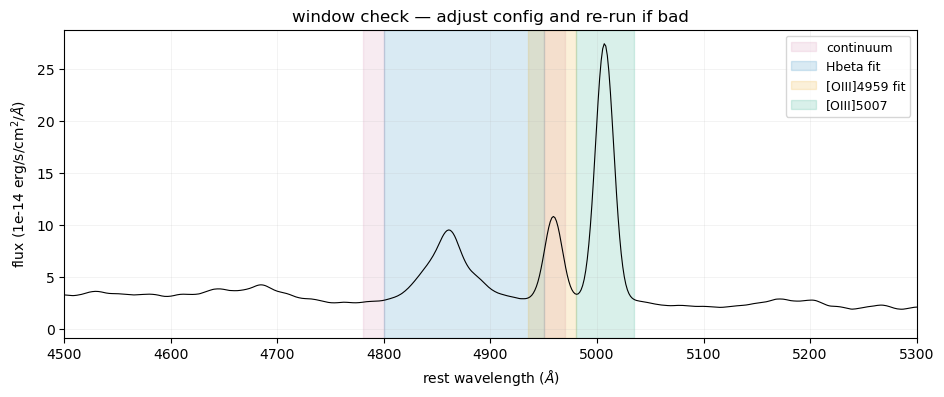

In [33]:
# ---------------- load + quick look: check the windows ----------------
data = np.loadtxt(SPEC_FILE)
wave, flux, err = data[:, 0], data[:, 1] / UNIT, data[:, 2] / UNIT

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wave, flux, color=C_DATA, lw=0.8)
for win, color, lab in [(CONTI_LEFT, C_CON, 'continuum'),
                        (CONTI_RIGHT, C_CON, None),
                        (HB_WIN, C_BROAD, 'Hbeta fit'),
                        (OIII4959_WIN, C_MODEL, '[OIII]4959 fit'),
                        (OIII5007_WIN, C_NARROW, '[OIII]5007')]:
    ax.axvspan(win[0], win[1], color=color, alpha=0.15, label=lab)
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
ax.set_title('window check — adjust config and re-run if bad')
ax.set_xlim(4500, 5300)
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

In [34]:
# ---------------- pipeline (one full pass) ----------------
def run_pipeline(wave, flux, err):
    # The [OIII] steps (1-2) run on the RAW flux: each carries its own local
    # linear continuum/background, so the global continuum plays no role
    # there. The global linear continuum is subtracted only for the Hbeta
    # fit (step 3), and is measured on the NARROW-SUBTRACTED flux.

    # ---- step 1: subtract [OIII]4959 using the 5007 profile
    o1, o2 = OIII5007_WIN
    idx = np.where((wave >= o1) & (wave <= o2))[0]
    wave_o1s, flux_o1s = wave[idx], flux[idx]
    fl, wl = window_median(wave, flux, o1 - 2, o1)
    fr, wr = window_median(wave, flux, o2, o2 + 3)
    fcon_o1s = linear_through(wl, fl, wr, fr, wave_o1s)
    flux_o1s = flux_o1s - fcon_o1s

    def model_4959(params, w, with_background=True):
        m = np.interp(w, wave_o1s - params['oiii_diff'],
                      flux_o1s / params['oiii_ratio'], left=0.0, right=0.0)
        if with_background:
            m = m + params['a_bak'] + params['b_bak'] * w
        return m

    def resi_4959(params, w, f, e):
        return (f - model_4959(params, w)) / e

    pars1 = Parameters()
    pars1.add('oiii_diff', value=5007.0 - 4959.0)
    pars1.add('a_bak', value=0.0)
    pars1.add('b_bak', value=0.0)
    pars1.add('oiii_ratio', value=3.0)

    idx49 = np.where((wave >= OIII4959_WIN[0]) & (wave <= OIII4959_WIN[1]))[0]
    out1 = minimize(resi_4959, pars1,
                    args=(wave[idx49], flux[idx49], err[idx49]))

    narrow_4959 = model_4959(out1.params, wave, with_background=False)
    flux1 = flux - narrow_4959

    # ---- step 2: clean [OIII]5007 profile (the narrow template)
    fl, wl = window_median(wave, flux1, o1 - 2, o1 + 3)
    fr, wr = window_median(wave, flux1, o2 - 2, o2 + 3)
    wave_t = wave[idx]
    fcon_5007 = linear_through(wl, fl, wr, fr, wave_t)
    flux_t = flux1[idx] - fcon_5007
    err_t = err[idx]

    narrow_5007 = np.interp(wave, wave_t, flux_t, left=0.0, right=0.0)

    # ---- step 3: Hbeta = narrow template + 2 Gaussians + constant
    # Global linear continuum subtracted here only, and measured on the
    # NARROW-SUBTRACTED flux: continuum windows may sit near [OIII]
    # (broad Hbeta extends underneath), and the fitted narrow lines must
    # not be counted in the continuum level (avoids double subtraction).
    flux_ns = flux1 - narrow_5007
    fl, wl = window_median(wave, flux_ns, *CONTI_LEFT)
    fr, wr = window_median(wave, flux_ns, *CONTI_RIGHT)
    fcon_tot = linear_through(wl, fl, wr, fr, wave)
    fluxc = flux_ns - fcon_tot

    hb1, hb2 = HB_WIN
    idxhb = np.where((wave >= hb1) & (wave <= hb2))[0]
    wave_hb, flux_hb, err_hb = wave[idxhb], fluxc[idxhb], err[idxhb]

    def hb_narrow(params, w):
        return np.interp(w, wave_t - params['shift'],
                         flux_t / params['ratio'], left=0.0, right=0.0)

    def hb_broad(params, w):
        g1 = gauss(w, params['p0'], params['p1'], params['p2'])
        g2 = gauss(w, params['p3'], params['p4'], params['p5'])
        return g1 + g2 + params['p6']

    def resi_hb(params, w, f, e):
        return (f - hb_narrow(params, w) - hb_broad(params, w)) / e

    # Amplitude guesses from the integrated window flux, centers/shift
    # bounded: fixed small guesses can fall into a local minimum with a
    # Gaussian far outside the window.
    dlam = np.median(np.diff(wave_hb))
    area0 = max(np.sum(flux_hb) * dlam, 10.0 * dlam)
    shift0 = 5007.0 - 4861.0

    pars3 = Parameters()
    pars3.add('shift', value=shift0, min=shift0 - 20.0, max=shift0 + 20.0)
    pars3.add('ratio', value=10.0, min=1.0, max=15.0)
    pars3.add('p0', value=0.3 * area0, min=0.0)
    pars3.add('p1', value=4861.0, min=hb1, max=hb2)
    pars3.add('p2', value=2000.0 / 3.0e5 * 4861.0,
              min=1000.0 / 3.0e5 * 4861.0)
    pars3.add('p3', value=0.5 * area0, min=0.0)
    pars3.add('p4', value=4861.0, min=hb1, max=hb2)
    pars3.add('p5', value=4000.0 / 3.0e5 * 4861.0,
              min=1000.0 / 3.0e5 * 4861.0)
    pars3.add('p6', value=0.0)

    out3 = minimize(resi_hb, pars3, args=(wave_hb, flux_hb, err_hb))

    narrow_hb = np.interp(wave, wave_hb, hb_narrow(out3.params, wave_hb),
                          left=0.0, right=0.0)

    narrow_total = narrow_4959 + narrow_5007 + narrow_hb
    flux_sub = flux - narrow_total  # broad Hbeta + continuum kept

    return {
        'flux_sub': flux_sub,
        'narrow_total': narrow_total,
        'narrow_4959': narrow_4959,
        'narrow_5007': narrow_5007,
        'narrow_hb': narrow_hb,
        'fcon_tot': fcon_tot,
        'wave_t': wave_t, 'flux_t': flux_t, 'err_t': err_t,
        'fcon_5007': fcon_5007,
        'wave_o1s': wave_o1s, 'flux_o1s': flux_o1s, 'fcon_o1s': fcon_o1s,
        'wave_hb': wave_hb, 'flux_hb': flux_hb,
        'hb_narrow_model': hb_narrow(out3.params, wave_hb),
        'hb_broad_model': hb_broad(out3.params, wave_hb),
        'out1': out1, 'out3': out3,
    }

In [35]:
# ---------------- best fit ----------------
r = run_pipeline(wave, flux, err)

print('[OIII] 5007/4959 ratio :', fmt_par(r['out1'].params['oiii_ratio']))
print('4959 center            : %.2f'
      % (5007.0 - r['out1'].params['oiii_diff'].value))
print('step-1 red. chi2       : %.3f' % r['out1'].redchi)
print('[OIII]/Hb narrow ratio :', fmt_par(r['out3'].params['ratio']))
print('narrow Hb center       : %.2f'
      % (5007.0 - r['out3'].params['shift'].value))
print('step-3 red. chi2       : %.3f' % r['out3'].redchi)

[OIII] 5007/4959 ratio : 3.0755 +/- 0.0112
4959 center            : 4959.01
step-1 red. chi2       : 5.447
[OIII]/Hb narrow ratio : 8.4592 +/- 0.1661
narrow Hb center       : 4861.58
step-3 red. chi2       : 2.074


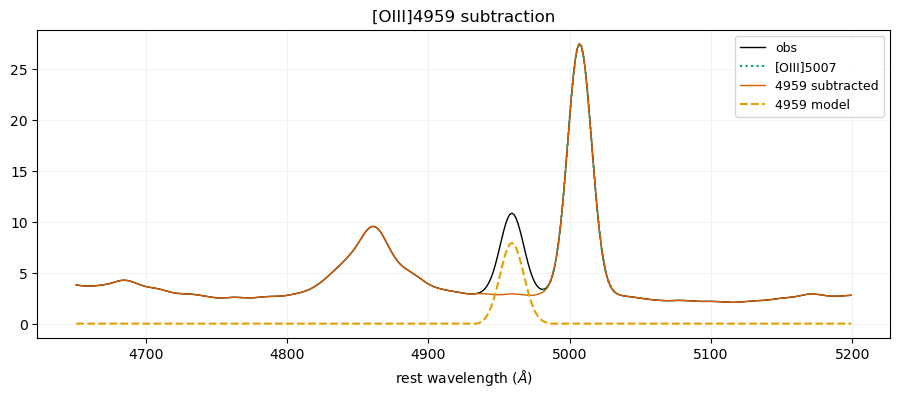

In [36]:
# ---------------- step 1 plot: [OIII]4959 subtraction (raw-flux space) ----------------
fig, ax = plt.subplots(figsize=(11, 4))
idx = np.where((wave >= 4650.0) & (wave <= 5200.0))[0]
ax.plot(wave[idx], flux[idx], color=C_DATA, lw=1.0, label='obs')
ax.plot(r['wave_o1s'], r['flux_o1s'] + r['fcon_o1s'], ':', color=C_NARROW,
        label='[OIII]5007')
ax.plot(wave[idx], (flux - r['narrow_4959'])[idx], color=C_SUB, lw=1.0,
        label='4959 subtracted')
ax.plot(wave[idx], r['narrow_4959'][idx], '--', color=C_MODEL,
        label='4959 model')
ax.set_title('[OIII]4959 subtraction')
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

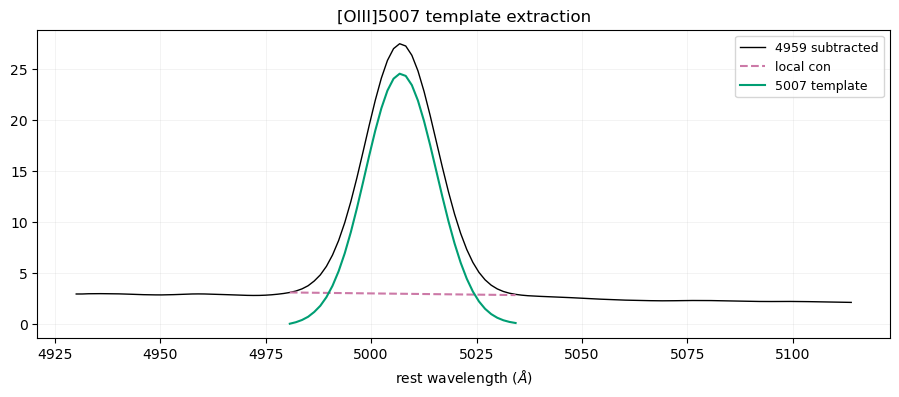

In [37]:
# ---------------- step 2 plot: [OIII]5007 template (raw-flux space) ----------------
fig, ax = plt.subplots(figsize=(11, 4))
idx = np.where((wave >= OIII5007_WIN[0] - 50) & (wave <= OIII5007_WIN[1] + 80))[0]
ax.plot(wave[idx], (flux - r['narrow_4959'])[idx], color=C_DATA, lw=1.0,
        label='4959 subtracted')
ax.plot(r['wave_t'], r['fcon_5007'], '--', color=C_CON, label='local con')
ax.plot(r['wave_t'], r['flux_t'], color=C_NARROW, label='5007 template')
ax.set_title('[OIII]5007 template extraction')
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

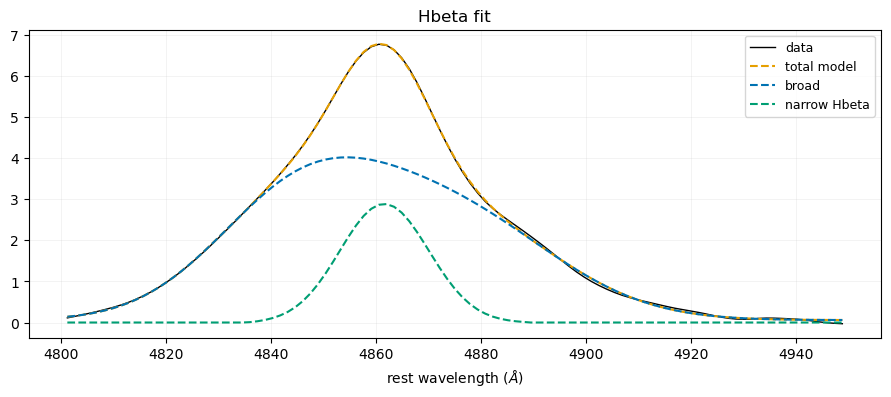

In [38]:
# ---------------- step 3 plot: Hbeta fit ----------------
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(r['wave_hb'], r['flux_hb'], color=C_DATA, lw=1.0, label='data')
ax.plot(r['wave_hb'], r['hb_narrow_model'] + r['hb_broad_model'], '--',
        color=C_MODEL, label='total model')
ax.plot(r['wave_hb'], r['hb_broad_model'], '--', color=C_BROAD,
        label='broad')
ax.plot(r['wave_hb'], r['hb_narrow_model'], '--', color=C_NARROW,
        label='narrow Hbeta')
ax.set_title('Hbeta fit')
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

In [39]:
# ---------------- Monte Carlo uncertainties ----------------
mc = dict()
if N_MC > 0:
    rng = np.random.default_rng(SEED)
    keys = ('narrow_total', 'narrow_4959', 'narrow_5007', 'narrow_hb',
            'flux_t')
    stacks = {k: [] for k in keys}
    samples = {k: [] for k in ('oiii_ratio', 'oiii_diff', 'ratio', 'shift')}
    nfail = 0
    for _ in range(N_MC):
        f_pert = flux + err * rng.standard_normal(flux.size)
        try:
            ri = run_pipeline(wave, f_pert, err)
        except Exception:
            nfail += 1
            continue
        for k in keys:
            stacks[k].append(ri[k])
        samples['oiii_ratio'].append(ri['out1'].params['oiii_ratio'].value)
        samples['oiii_diff'].append(ri['out1'].params['oiii_diff'].value)
        samples['ratio'].append(ri['out3'].params['ratio'].value)
        samples['shift'].append(ri['out3'].params['shift'].value)

    mc = {'nfail': nfail}
    for k in keys:
        mc['sig_' + k] = np.std(np.array(stacks[k]), axis=0, ddof=1)
    for k, v in samples.items():
        arr = np.array(v)
        mc[k] = (np.median(arr), np.std(arr, ddof=1))

    if nfail:
        print('failed realizations    : %d / %d' % (nfail, N_MC))
    print('[OIII] 5007/4959 ratio : %.4f +/- %.4f' % mc['oiii_ratio'])
    print('[OIII]/Hb narrow ratio : %.4f +/- %.4f' % mc['ratio'])
    print('narrow Hb center       : %.2f +/- %.2f'
          % (5007.0 - mc['shift'][0], mc['shift'][1]))

sig_total = mc['sig_narrow_total'] if mc else np.zeros_like(wave)
err_out = np.sqrt(err**2 + sig_total**2)

[OIII] 5007/4959 ratio : 3.0755 +/- 0.0050
[OIII]/Hb narrow ratio : 8.4632 +/- 0.1268
narrow Hb center       : 4861.58 +/- 0.07


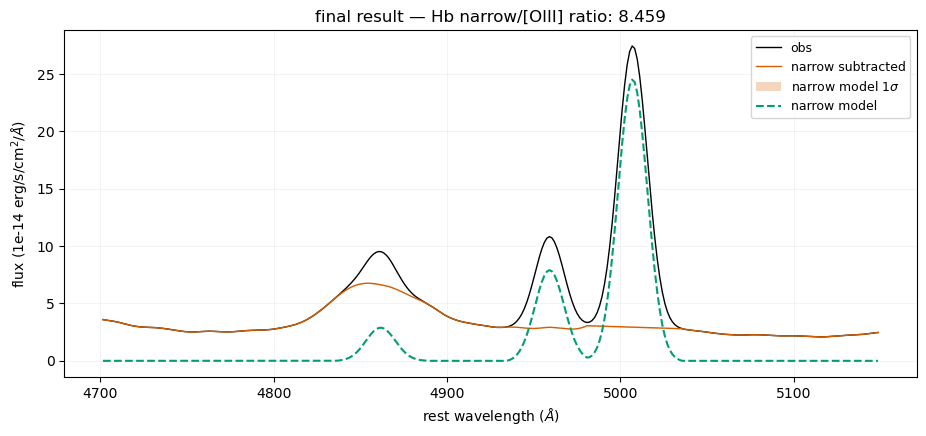

In [40]:
# ---------------- final result plot ----------------
fig, ax = plt.subplots(figsize=(11, 4.5))
idx = np.where((wave >= 4700.0) & (wave <= 5150.0))[0]
ax.plot(wave[idx], flux[idx], color=C_DATA, lw=1.0, label='obs')
ax.plot(wave[idx], r['flux_sub'][idx], color=C_SUB, lw=1.0,
        label='narrow subtracted')
if mc:
    ax.fill_between(wave[idx],
                    (r['flux_sub'] - mc['sig_narrow_total'])[idx],
                    (r['flux_sub'] + mc['sig_narrow_total'])[idx],
                    color=C_SUB, alpha=0.25, lw=0,
                    label='narrow model 1$\\sigma$')
ax.plot(wave[idx], r['narrow_total'][idx], '--', color=C_NARROW,
        label='narrow model')
ax.set_title('final result — Hb narrow/[OIII] ratio: %.3f'
             % r['out3'].params['ratio'].value)
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
fig.savefig('%s_subtract_narrow_mean.pdf' % OBJ, bbox_inches='tight')
plt.show()

In [41]:
# ---------------- write outputs ----------------
# narrow-subtracted spectrum, same 3-column format as the original
outname = SPEC_FILE + '.subnarrow'
with open(outname, 'w') as f:
    for i in range(wave.size):
        f.write('%f  %e  %e\n'
                % (wave[i], r['flux_sub'][i] * UNIT, err_out[i] * UNIT))
print('subtracted spectrum :', outname)

# narrow model and components on the full grid
zeros = np.zeros_like(wave)
sig = {k: (mc['sig_' + k] if mc else zeros)
       for k in ('narrow_total', 'narrow_4959', 'narrow_5007', 'narrow_hb')}
profname = '%s_narrow_profile.txt' % OBJ
np.savetxt(profname,
           np.column_stack([wave,
                            r['narrow_total'] * UNIT, sig['narrow_total'] * UNIT,
                            r['narrow_5007'] * UNIT, sig['narrow_5007'] * UNIT,
                            r['narrow_4959'] * UNIT, sig['narrow_4959'] * UNIT,
                            r['narrow_hb'] * UNIT, sig['narrow_hb'] * UNIT]),
           fmt='%f  ' + '  '.join(['%e'] * 8),
           header='wave  narrow_total  sig_total  oiii5007  sig_5007  '
                  'oiii4959  sig_4959  narrow_hb  sig_hb   (flux x %g)' % UNIT)
print('narrow profile      :', profname)

# clean [OIII]5007 template
sig_t = mc['sig_flux_t'] if mc else np.zeros_like(r['wave_t'])
tmplname = '%s_oiii5007_template.txt' % OBJ
np.savetxt(tmplname,
           np.column_stack([r['wave_t'], r['flux_t'] * UNIT,
                            r['err_t'] * UNIT, sig_t * UNIT]),
           fmt='%f  %e  %e  %e',
           header='wave  flux  err_data  sig_mc   (flux x %g)' % UNIT)
print('[OIII]5007 template :', tmplname)

subtracted spectrum : spec_mean_hbeta.txt.subnarrow
narrow profile      : NGC3227_narrow_profile.txt
[OIII]5007 template : NGC3227_oiii5007_template.txt
